**1. Setup and Imports**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import joblib
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded")

Libraries loaded


**2. Data Loading and Rebuilding the Model**

In [ ]:
# Load data from your GitHub (UPDATE USERNAME if you changed it)
df = pd.read_csv('https://raw.githubusercontent.com/pallabiroysingh/insurance-cost-prediction/main/data/insurance.csv')
df['BMI'] = df['Weight'] / (df['Height'] / 100) ** 2

X = df.drop(columns=['PremiumPrice'])
y = df['PremiumPrice']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Retrain the tuned model (since we can't load .pkl from old account)
model = RandomForestRegressor(n_estimators=200, min_samples_split=10,
                               min_samples_leaf=2, max_features=None,
                               random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

from sklearn.metrics import r2_score, mean_absolute_error
print(f"R²:  {r2_score(y_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):,.0f}")

R²:  0.9049
MAE: 1,007


**3. Learning Curves**

Checking whether our model would benefit from more training data, and how much overfitting exists between training and validation performance.

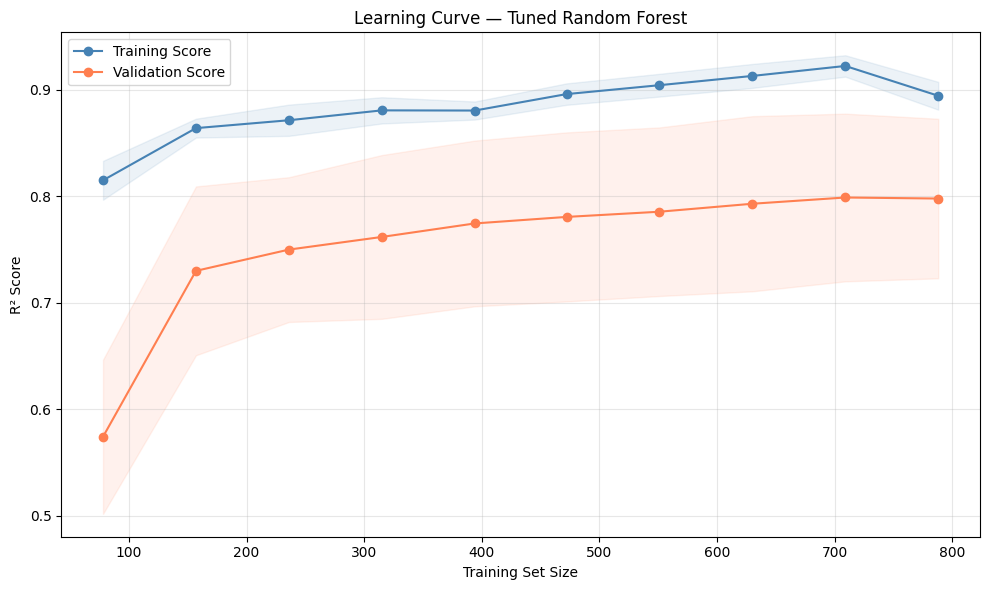

Training score at full data:   0.8945
Validation score at full data: 0.7980
Gap: 0.0965


In [3]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    RandomForestRegressor(n_estimators=200, min_samples_split=10,
                          min_samples_leaf=2, random_state=42),
    X, y, cv=5, scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label='Training Score', color='steelblue', marker='o')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='steelblue')
plt.plot(train_sizes, val_mean, label='Validation Score', color='coral', marker='o')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='coral')
plt.title('Learning Curve — Tuned Random Forest')
plt.xlabel('Training Set Size')
plt.ylabel('R² Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Training score at full data:   {train_mean[-1]:.4f}")
print(f"Validation score at full data: {val_mean[-1]:.4f}")
print(f"Gap: {train_mean[-1] - val_mean[-1]:.4f}")

**4. Prediction Intervals**

Instead of giving a single predicted number, we provide a confidence range. This helps stakeholders understand how certain the model is about each prediction; critical for pricing decisions where false precision is dangerous.

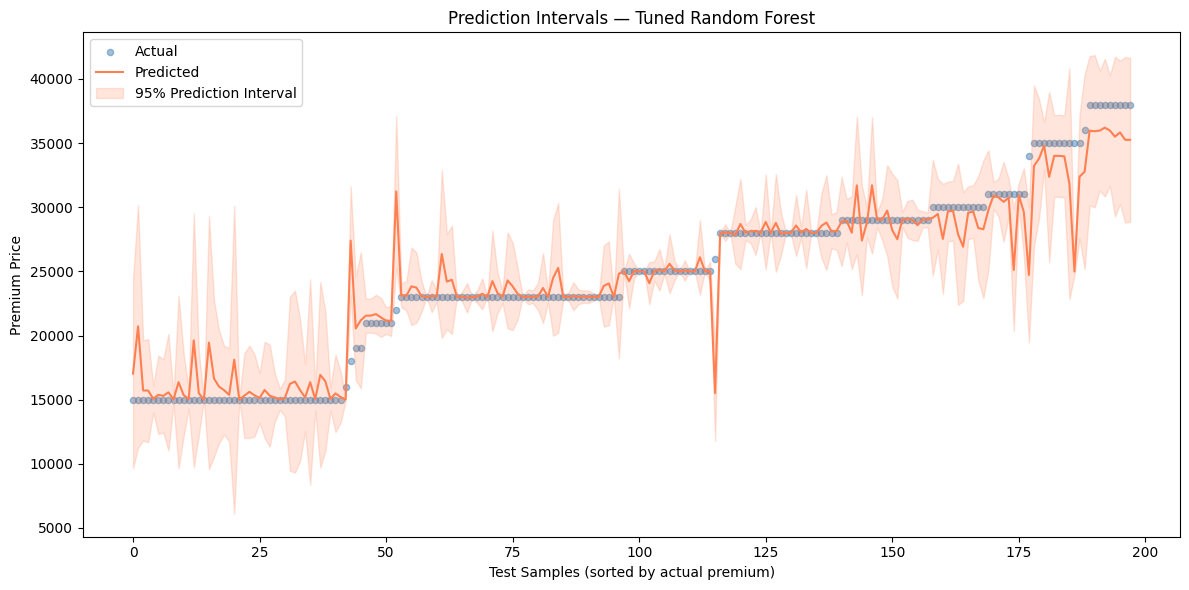

95% Prediction Interval Coverage: 96.5%
Average Interval Width: 5,455


In [5]:
all_tree_preds = np.array([tree.predict(X_test) for tree in model.estimators_])

pred_mean = all_tree_preds.mean(axis=0)
pred_std = all_tree_preds.std(axis=0)
lower = pred_mean - 1.96 * pred_std
upper = pred_mean + 1.96 * pred_std

sorted_idx = np.argsort(y_test.values)
y_sorted = y_test.values[sorted_idx]
mean_sorted = pred_mean[sorted_idx]
lower_sorted = lower[sorted_idx]
upper_sorted = upper[sorted_idx]

plt.figure(figsize=(12, 6))
plt.scatter(range(len(y_sorted)), y_sorted, alpha=0.5, color='steelblue', label='Actual', s=20)
plt.plot(range(len(mean_sorted)), mean_sorted, color='coral', label='Predicted', linewidth=1.5)
plt.fill_between(range(len(lower_sorted)), lower_sorted, upper_sorted, alpha=0.2, color='coral', label='95% Prediction Interval')
plt.title('Prediction Intervals — Tuned Random Forest')
plt.xlabel('Test Samples (sorted by actual premium)')
plt.ylabel('Premium Price')
plt.legend()
plt.tight_layout()
plt.show()

coverage = np.mean((y_test.values >= lower) & (y_test.values <= upper)) * 100
avg_width = np.mean(upper - lower)
print(f"95% Prediction Interval Coverage: {coverage:.1f}%")
print(f"Average Interval Width: {avg_width:,.0f}")

**5. SHAP Values**

Feature importance tells us which features matter overall. SHAP goes deeper; it shows how each feature pushes an individual prediction up or down, enabling model explainability for regulators and business stakeholders.

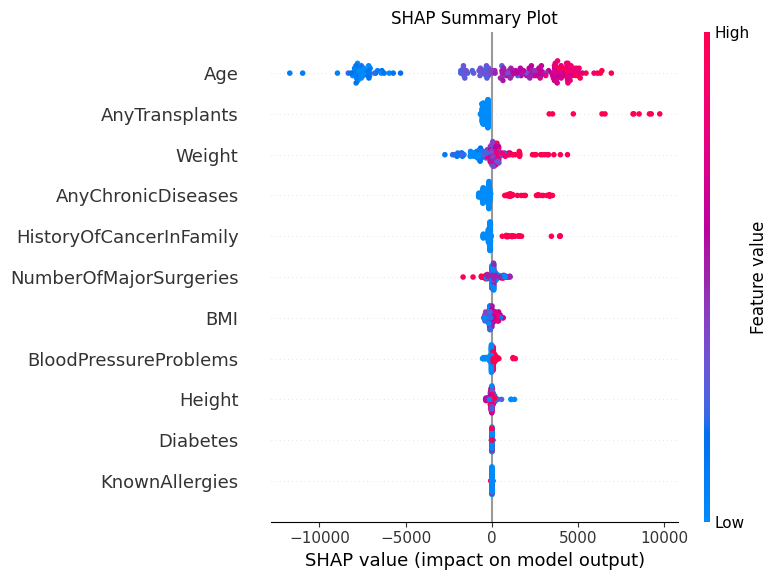

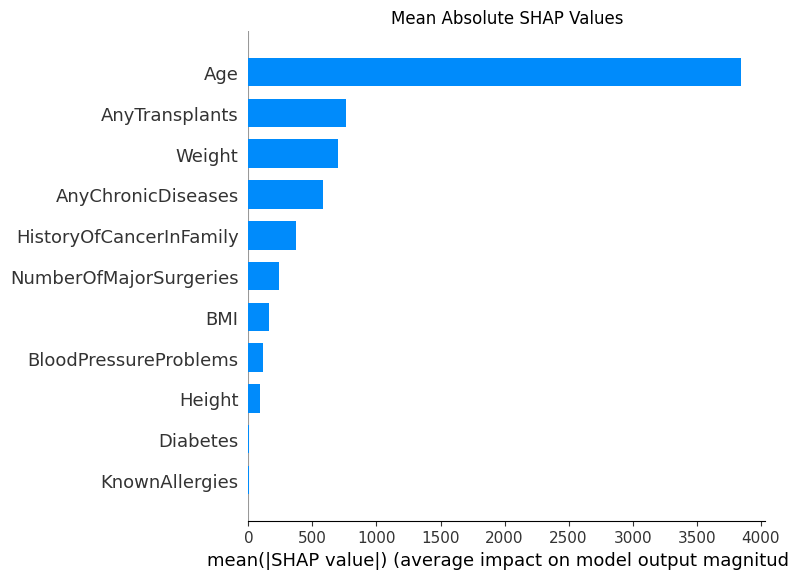

In [6]:
!pip install shap -q

import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Summary plot — global feature importance with direction
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Summary Plot')
plt.tight_layout()
plt.show()

# Bar plot — average absolute SHAP values
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.title('Mean Absolute SHAP Values')
plt.tight_layout()
plt.show()

**6. Error Analysis**

Overall metrics like MAE hide where the model struggles. Error analysis identifies which types of individuals the model gets wrong, helping us understand limitations and prioritize improvements.

TOP 10 WORST PREDICTIONS
Actual:   26,000 | Predicted:   15,507 | Error:  +10,493 | Age: 18 | Transplant: 0
Actual:   35,000 | Predicted:   24,986 | Error:  +10,014 | Age: 66 | Transplant: 0
Actual:   18,000 | Predicted:   27,393 | Error:   -9,393 | Age: 43 | Transplant: 0
Actual:   34,000 | Predicted:   24,721 | Error:   +9,279 | Age: 42 | Transplant: 0
Actual:   22,000 | Predicted:   31,225 | Error:   -9,225 | Age: 46 | Transplant: 0
Actual:   31,000 | Predicted:   25,104 | Error:   +5,896 | Age: 35 | Transplant: 0
Actual:   15,000 | Predicted:   20,715 | Error:   -5,715 | Age: 28 | Transplant: 0
Actual:   15,000 | Predicted:   19,623 | Error:   -4,623 | Age: 23 | Transplant: 0
Actual:   15,000 | Predicted:   19,445 | Error:   -4,445 | Age: 27 | Transplant: 0
Actual:   23,000 | Predicted:   26,352 | Error:   -3,352 | Age: 43 | Transplant: 0

Average age of worst predictions: 37.1
Average age of all test data:     41.8
Transplant rate in worst predictions: 0.0%
Transplant rate in all 

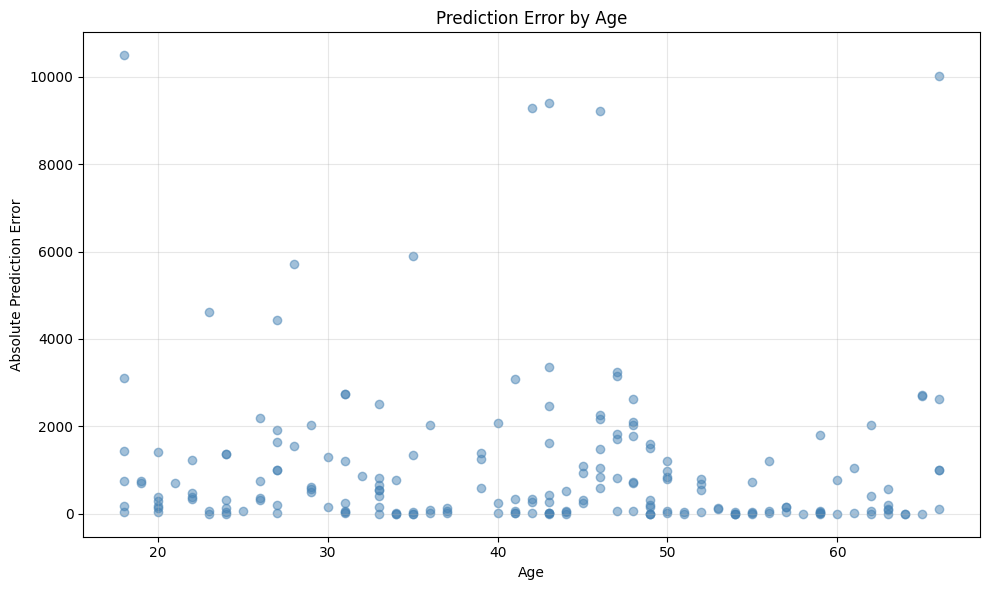

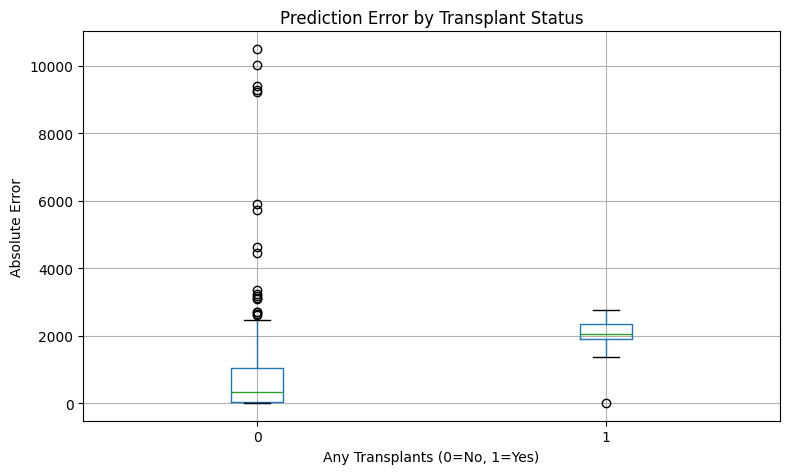

In [7]:
# Find worst predictions
error_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Error': y_test.values - y_pred,
    'Abs_Error': np.abs(y_test.values - y_pred)
})

# Add features back
error_df = pd.concat([error_df, X_test.reset_index(drop=True)], axis=1)

# Top 10 worst predictions
print("TOP 10 WORST PREDICTIONS")
print("=" * 60)
worst = error_df.nlargest(10, 'Abs_Error')
for i, row in worst.iterrows():
    print(f"Actual: {row['Actual']:>8,.0f} | Predicted: {row['Predicted']:>8,.0f} | Error: {row['Error']:>+8,.0f} | Age: {row['Age']:.0f} | Transplant: {row['AnyTransplants']:.0f}")

print(f"\nAverage age of worst predictions: {worst['Age'].mean():.1f}")
print(f"Average age of all test data:     {error_df['Age'].mean():.1f}")
print(f"Transplant rate in worst predictions: {worst['AnyTransplants'].mean():.1%}")
print(f"Transplant rate in all test data:     {error_df['AnyTransplants'].mean():.1%}")

# Visualize errors by age
plt.figure(figsize=(10, 6))
plt.scatter(error_df['Age'], error_df['Abs_Error'], alpha=0.5, color='steelblue')
plt.xlabel('Age')
plt.ylabel('Absolute Prediction Error')
plt.title('Prediction Error by Age')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Error distribution by transplant status
fig, ax = plt.subplots(figsize=(8, 5))
error_df.boxplot(column='Abs_Error', by='AnyTransplants', ax=ax)
plt.title('Prediction Error by Transplant Status')
plt.suptitle('')
plt.xlabel('Any Transplants (0=No, 1=Yes)')
plt.ylabel('Absolute Error')
plt.tight_layout()
plt.show()

**7. Business Impact Framing**

Translating model performance from technical metrics into business value. An MAE of 1,007 means nothing to a business leader — but "reduces pricing error by X% across 10,000 policies" drives decisions.

In [8]:
# Compare model vs naive approach (predicting mean for everyone)
mean_premium = y_train.mean()
naive_errors = np.abs(y_test.values - mean_premium)
model_errors = np.abs(y_test.values - y_pred)

naive_mae = naive_errors.mean()
model_mae = model_errors.mean()
improvement = ((naive_mae - model_mae) / naive_mae) * 100

print("BUSINESS IMPACT ANALYSIS")
print("=" * 60)
print(f"Naive approach (predict mean for everyone): MAE = {naive_mae:,.0f}")
print(f"Our model:                                  MAE = {model_mae:,.0f}")
print(f"Improvement:                                {improvement:.1f}%")
print()

# Scale to business
policies = [1000, 10000, 100000]
print("SCALED IMPACT:")
print(f"{'Policies':<12} {'Naive Total Error':>18} {'Model Total Error':>18} {'Savings':>12}")
print("-" * 65)
for n in policies:
    naive_total = naive_mae * n
    model_total = model_mae * n
    saving = naive_total - model_total
    print(f"{n:<12,} {naive_total:>18,.0f} {model_total:>18,.0f} {saving:>12,.0f}")

print(f"\nKEY INSIGHT:")
print(f"For every 10,000 policies priced, our model reduces")
print(f"total pricing error by approximately {(naive_mae - model_mae) * 10000:,.0f} compared")
print(f"to using the average premium for everyone.")
print(f"\nThis translates to more competitive premiums for low-risk")
print(f"individuals and appropriate pricing for high-risk individuals,")
print(f"reducing both customer churn and adverse selection risk.")

BUSINESS IMPACT ANALYSIS
Naive approach (predict mean for everyone): MAE = 5,308
Our model:                                  MAE = 1,007
Improvement:                                81.0%

SCALED IMPACT:
Policies      Naive Total Error  Model Total Error      Savings
-----------------------------------------------------------------
1,000                 5,307,696          1,007,452    4,300,245
10,000               53,076,963         10,074,515   43,002,447
100,000             530,769,625        100,745,154  430,024,471

KEY INSIGHT:
For every 10,000 policies priced, our model reduces
total pricing error by approximately 43,002,447 compared
to using the average premium for everyone.

This translates to more competitive premiums for low-risk
individuals and appropriate pricing for high-risk individuals,
reducing both customer churn and adverse selection risk.


## Post-Model Analysis: Key Findings

### SHAP Values
- Age has the largest SHAP impact (~3,900 average), confirming it as the dominant predictor
- High age pushes predictions up by as much as 10,000; low age pushes down by 10,000
- AnyTransplants shows a one-directional effect — having a transplant always increases the predicted premium significantly
- Diabetes and KnownAllergies have near-zero SHAP values, confirming they add no predictive value

### Error Analysis
- Worst predictions occur at age extremes (young people with high premiums, older people with low premiums)
- The model is consistently off by ~2,200 for transplant patients but produces the largest individual errors (9,000-10,500) for non-transplant patients
- These extreme errors likely come from individuals whose risk profiles don't match typical age-based patterns — possibly young people with rare severe conditions not captured in our features

### Business Impact
- Model reduces pricing error by 81% compared to using the average premium for everyone
- For every 10,000 policies priced, total pricing error drops by approximately 43 million
- This enables more competitive premiums for low-risk individuals and appropriate pricing for high-risk individuals

### Recommendations
1. Collect more data; learning curves show the model hasn't plateaued (validation R² = 0.798)
2. Investigate the extreme error cases; young individuals with very high premiums may need additional features (lifestyle, occupation, detailed medical history) to predict accurately
3. Use prediction intervals (±2,700 average) when communicating predictions to stakeholders rather than false single-point precision
4. Consider dropping Diabetes, KnownAllergies, and Height from the model; they contribute no predictive value and add unnecessary complexity